## 1. What this notebook computes

A *condensate* is a configuration of the field that is the same at every place:
it depends on the time $x_4$ only. This notebook builds the exact condensates of
the commuting field dirac16complex00 with the potential
$U(S) = \frac{\lambda}{2}S^2$ in the author's metric and studies their
energy-momentum tensor. It

- shows that the number $S = \bar\Phi\Phi$ can have either sign (a histogram);
- builds the exact solution
  $\Phi(x_4) = (\cosh(kx_4) + \frac{\sinh(kx_4)}{k}M)\chi$ of the Revision
  record, checks the field equation and that $S$ stays constant, for one
  condensate that oscillates and one that grows;
- computes from the solution the energy density $\rho$ and the pressure $p$ and
  checks the record's values $\rho = mS + U$ and $p = SU' - U$, the same in all
  seven directions, and the vanishing of the $x_4$-$x_8$ component;
- measures the equation of state $w = p/\rho$ of actual solutions and compares it
  with $w = \lambda S/(2m + \lambda S)$; finds where $w = -1$;
- maps where condensates oscillate and where they grow;
- shows with toy fluids (an ILLUSTRATION, not solutions of the field equations)
  how energy flows between 3-space and the extra times when $p_3 \neq p_t$, and
  that a condensate, with $p_3 = p_t$, exchanges none;
- shows that the energy of the commuting field has no lower bound;
- draws seven teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 09b (Homogeneous condensates: energy, pressure, equation of state and energy
exchange) is the file `Revision/textbook/notebooks/09b_condensates.ipynb` of the
repository Dirac_claude. It builds the exact homogeneous solutions (condensates) of the
commuting field dirac16complex00 with the potential U = (lambda/2) S^2 in the author's
metric from the Revision gamma matrices, checks that S stays constant and that the energy
density and pressure are rho = m S + U and p = S U' - U in every direction, measures the
equation of state w = p/rho of actual solutions against lambda S/m, maps where
condensates oscillate or grow, shows with assumed toy fluids how energy is exchanged
between 3-space and the extra times when the two pressures differ (and that a condensate
exchanges none), and shows that the energy of the commuting field has no lower bound, in
seven teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 09b_condensates.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 09b_condensates.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
09b_condensates.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/09b.captions.json`
- `Revision/textbook/figures/09b_1_sign_of_s.png`
- `Revision/textbook/figures/09b_2_condensate_solutions.png`
- `Revision/textbook/figures/09b_3_energy_and_pressure.png`
- `Revision/textbook/figures/09b_4_equation_of_state.png`
- `Revision/textbook/figures/09b_5_regime_map.png`
- `Revision/textbook/figures/09b_6_energy_exchange.png`
- `Revision/textbook/figures/09b_7_energy_sign.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the seven figures of this notebook are saved and captioned
    ALL 33 CHECKS PASSED (notebook 09b)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/09b_condensates.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 09b_condensates.ipynb
      python -m nbconvert --execute --inplace 09b_condensates.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "KeyError" with the words "has no check": the notebook asks a Revision report for the
  verdict of one of its checks, and the report in your copy of the repository does not
  contain that check: your copy is older or newer than the notebook. Run `git pull` in
  the repository folder, then run the notebook again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 09b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 09b (Homogeneous condensates: energy, pressure, equation of state and energy
# exchange) is the file Revision/textbook/notebooks/09b_condensates.ipynb of the
# repository Dirac_claude. It builds the exact homogeneous solutions (condensates) of the
# commuting field dirac16complex00 with the potential U = (lambda/2) S^2 in the author's
# metric from the Revision gamma matrices, checks that S stays constant and that the
# energy density and pressure are rho = m S + U and p = S U' - U in every direction,
# measures the equation of state w = p/rho of actual solutions against lambda S/m, maps
# where condensates oscillate or grow, shows with assumed toy fluids how energy is
# exchanged between 3-space and the extra times when the two pressures differ (and that a
# condensate exchanges none), and shows that the energy of the commuting field has no
# lower bound, in seven teaching plots. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy and matplotlib; the other packages run Jupyter, the
# program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 09b_condensates.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 09b_condensates.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 09b_condensates.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/09b.captions.json
# - Revision/textbook/figures/09b_1_sign_of_s.png
# - Revision/textbook/figures/09b_2_condensate_solutions.png
# - Revision/textbook/figures/09b_3_energy_and_pressure.png
# - Revision/textbook/figures/09b_4_equation_of_state.png
# - Revision/textbook/figures/09b_5_regime_map.png
# - Revision/textbook/figures/09b_6_energy_exchange.png
# - Revision/textbook/figures/09b_7_energy_sign.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the seven figures of this notebook are saved and captioned
#     ALL 33 CHECKS PASSED (notebook 09b)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/09b_condensates.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 09b_condensates.ipynb
#     python -m nbconvert --execute --inplace 09b_condensates.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "KeyError" with the words "has no check": the notebook asks a Revision report for the
#   verdict of one of its checks, and the report in your copy of the repository does not
#   contain that check: your copy is older or newer than the notebook. Run git pull in
#   the repository folder, then run the notebook again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "09b"  # this notebook: chapter 09, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 09b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Condensate (homogeneous configuration)**: a field that depends only on the
  time $x_4$, not on $x_1, x_2, x_3, x_5, x_6, x_7, x_8$.
- **Effective mass** $V = m + U'(S) = m + \lambda S$: the number that multiplies
  $\Phi$ on the right side of the field equation.
- **Matrix exponential**: for a square matrix $M$ the matrix
  $e^{Mx_4} = 1 + Mx_4 + \frac{1}{2}M^2x_4^2 + \dots$; the column
  $e^{Mx_4}\chi$ solves $\frac{d}{dx_4}\Phi = M\Phi$ with $\Phi(0) = \chi$. When
  $M^2 = k^2$ times the unit matrix, the series sums to
  $\cosh(kx_4) + \frac{\sinh(kx_4)}{k}M$.
- **Oscillating / growing**: when $k^2 < 0$ the number $k$ is imaginary,
  $\cosh(kx_4)$ becomes a cosine and the solution oscillates; when $k^2 > 0$ it
  contains $e^{kx_4}$ and grows.
- **Energy density** $\rho$, **pressure** $p$, **equation of state** $w = p/\rho$.
  Dust has $w = 0$, radiation $w = 1/3$, a cosmological constant $w = -1$; a
  value $w < -1$ is called *phantom*.
- **Energy exchange**: the change of the energy density in time caused by work
  done by the inflating 3-space and the deflating extra times.
- **Toy fluid (ILLUSTRATION)**: a source with assumed pressures $p_3 = w_3\rho$
  and $p_t = w_t\rho$, used only to show what the conservation identity does; it
  is not a solution of the field equations of this book.
- **Runge-Kutta method (RK4)**: a step-by-step method that solves a differential
  equation numerically with four slope evaluations per step.
- **Histogram**: a bar chart that counts how many numbers fall into each of a
  row of equal intervals.
- **Krein (indefinite) form**: the form $\Phi^\dagger B\Phi$ built with the
  matrix $B$, which has eight eigenvalues $+1$ and eight eigenvalues $-1$; it can
  be positive or negative.

## 4. The physical and mathematical situation

**The field equation of a condensate.** In the author's metric the field
equation of dirac16complex00 is
$\sum_a\frac{1}{f_a}\gamma^{(a)}\partial_a\Phi + 3H\gamma^{(8)}\Phi = V\Phi$ with
$V = m + \lambda S$. For a condensate every derivative except $\partial_4$ is
zero, and $f_4 = 1$, so the equation is
$\gamma^{(4)}\partial_4\Phi + 3H\gamma^{(8)}\Phi = V\Phi$. Multiplying by
$-\gamma^{(4)}$ and using $(\gamma^{(4)})^2 = -1$ gives
$\partial_4\Phi = M\Phi$ with $M = -V\gamma^{(4)} + 3H\gamma^{(4)}\gamma^{(8)}$.
Neither $a_4$ nor $x_8$ appears: the same condensate solves the equation on
every history $a_4(x_4)$, the deflating one included.

**The exact solution** (Revision record, `Revision/theory/field-theory.json`,
formula `exact_solutions`): $M^2 = k^2$ with $k^2 = 9H^2 - V^2$, and
$M^TC + CM = 0$, so $S = \Phi^\dagger C\Phi$ does not change with $x_4$; then $V$
is a constant and $\Phi = (\cosh(kx_4) + \frac{\sinh(kx_4)}{k}M)\chi$
with $S = S_0 = \chi^\dagger C\chi$.

**Its energy-momentum tensor** (formula `EMT_homogeneous_on_shell`): only $K_4$
is nonzero, $K_4 = VS$ on shell, so $\rho = mS + U$ and
$p_3 = p_t = p_8 = SU' - U$; for $U = \frac{\lambda}{2}S^2$:
$\rho = mS + \frac{\lambda}{2}S^2$, $p = \frac{\lambda}{2}S^2$ and
$w = \lambda S/(2m + \lambda S)$.

**Energy exchange** (formula `energy_exchange`): conservation gives
$d\rho/dx_4 = -3a_4'(p_3 - p_t)$. A condensate has $p_3 = p_t$, so its energy
density is constant along every history.

**What is not computed here.** The equation of state that an observer living in
3-space would infer (after integrating over the hidden direction and the extra
times), its time dependence and any comparison with supernova data are not part
of the Revision record: they are OPEN. The $w$ of this notebook is the ratio
$p/\rho$ of the 8-dimensional tensor. The condensate's off-diagonal entries,
which are not zero in general, are not used here.

## 5. The matrices C and B, and the sign of S

The next cell reads the Revision fixture (the gammas $\gamma^{(x_1)}, \dots,
\gamma^{(x_8)}$, the matrix $C$ and the matrix $B = -iC\gamma^{(4)}$) and defines
the helper `recorded(path, name)`, which returns the verdict of a check in a
Revision report. The record says that $C = \mathrm{diag}(-\sigma, \sigma)$ with
an $8 \times 8$ matrix $\sigma$ that squares to 1 and has trace 0; so $C$ has
eight eigenvalues $+1$ and eight $-1$, and $S_0 = \chi^\dagger C\chi$ can be
positive or negative. The cell computes the eigenvalues of $C$ and the values of
$S_0$ for 20000 random columns $\chi$ of length 1.

In [2]:
import numpy as np  # arrays of numbers, matrices, linear algebra

fixture = json.loads(
    repository_file("Revision/algebra/gammas.json").read_text(encoding="utf-8"))
gamma = [np.array(rows, dtype=float) for rows in fixture["gamma"]]  # x1, ..., x8
C = np.array(fixture["C"], dtype=float)  # gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3)
B = (np.array(fixture["B"]["re"], dtype=float)  # B = -i C gamma^(x4), stored as its
     + 1j * np.array(fixture["B"]["im"], dtype=float))  # real and imaginary parts
I16 = np.eye(16)  # the 16 x 16 unit matrix
g4, g8 = gamma[3], gamma[7]  # gamma^(x4) and gamma^(x8)


def recorded(path, name):
    """The verdict (PASS or FAIL) of the check name in the Revision report path."""
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for item in report_data["checks"]:
        if item["name"] == name:
            return item["verdict"].upper()  # some reports write "pass"
    raise KeyError(f"{path} has no check {name}")


ALGEBRA_PY = "Revision/algebra/reports/python-algebra.json"
ALGEBRA_WL = "Revision/algebra/reports/wolfram-algebra.json"
eigenvalues_C = np.linalg.eigvalsh(C)  # C is symmetric: eigvalsh, sorted ascending
check(np.allclose(eigenvalues_C, [-1.0] * 8 + [1.0] * 8, atol=1e-12)
      and recorded(ALGEBRA_PY, "C_equals_notebook_sigma16") == "PASS"
      and recorded(ALGEBRA_WL, "sigma8_involution") == "PASS",
      "C has eight eigenvalues -1 and eight eigenvalues +1",
      record=f"{ALGEBRA_PY}, check C_equals_notebook_sigma16; {ALGEBRA_WL}, check "
             "sigma8_involution")
rng = np.random.default_rng(2026)  # a fixed seed: the same numbers in every run
chis = rng.normal(size=(20000, 16)) + 1j * rng.normal(size=(20000, 16))
chis /= np.linalg.norm(chis, axis=1)[:, None]  # every row now has length 1
# S0 = chi^dagger C chi for every row at once (einsum sums over the indices i, j).
S0_values = np.einsum("ni,ij,nj->n", chis.conj(), C, chis).real
negative_share = float(np.mean(S0_values < 0))  # the fraction of negative S0
check(S0_values.min() < 0 < S0_values.max() and np.abs(S0_values).max() <= 1 + 1e-12,
      "S0 = chi^dagger C chi takes both signs and lies between -1 and 1")
report("fraction of the 20000 random chi with S0 < 0", f"{negative_share:.4f}")

PASS C has eight eigenvalues -1 and eight eigenvalues +1
     reproduces Revision/algebra/reports/python-algebra.json, check
    C_equals_notebook_sigma16; Revision/algebra/reports/wolfram-algebra.json, check
    sigma8_involution
PASS S0 = chi^dagger C chi takes both signs and lies between -1 and 1
RESULT fraction of the 20000 random chi with S0 < 0 = 0.4983


The next cell draws the histogram of the 20000 values of $S_0$. A condensate
with $\lambda = 0$ has $\rho = mS_0$, so for $m > 0$ about half of these random
condensates have a negative energy density.

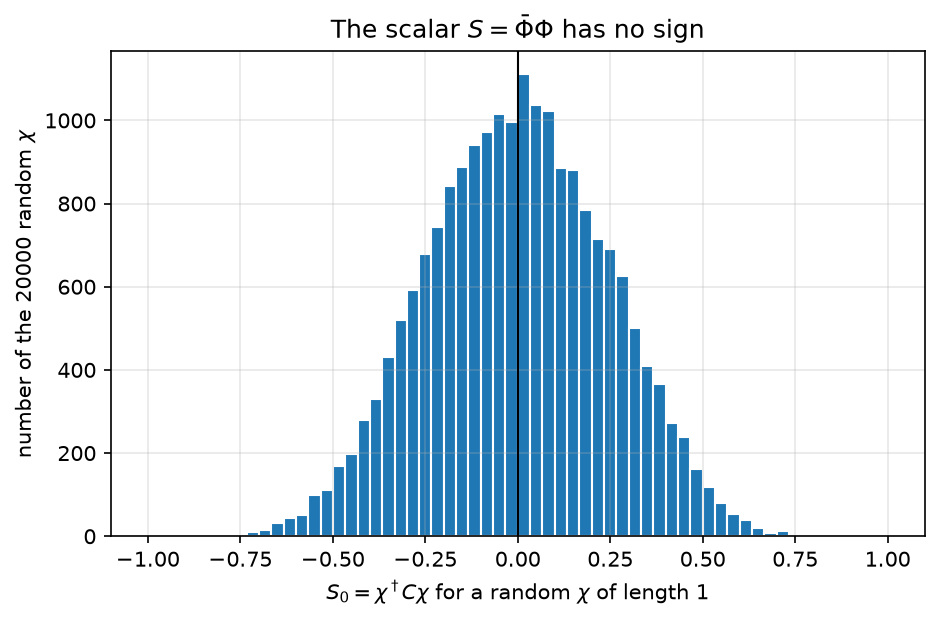

Figure 09b.1 saved as Revision/textbook/figures/09b_1_sign_of_s.png


In [3]:
fig, ax = plt.subplots()
ax.hist(S0_values, bins=60, range=(-1.0, 1.0), color="tab:blue", edgecolor="white")
ax.axvline(0.0, color="black", linewidth=1.0)
ax.set_xlabel("$S_0 = \\chi^\\dagger C \\chi$ for a random $\\chi$ of length 1")
ax.set_ylabel("number of the 20000 random $\\chi$")
ax.set_title("The scalar $S = \\bar\\Phi\\Phi$ has no sign")
save_figure(fig, "sign_of_s",
            "Histogram of $S_0 = \\chi^\\dagger C\\chi$ for 20000 random complex "
            "columns $\\chi$ of length 1 (fixed seed); horizontal axis $S_0$ (a pure "
            "number between $-1$ and $1$, because the eigenvalues of $C$ are $\\pm 1$), "
            "vertical axis the number of $\\chi$ in each of 60 intervals. The values "
            "are spread symmetrically about $0$: about half are negative. For a "
            "condensate with $\\lambda = 0$ the energy density is $\\rho = mS_0$, so "
            "its sign is the sign of $S_0$.")

## 6. The matrix M and its square

The next cell defines the function `condensate_matrix(V, H)`, which returns
$M = -V\gamma^{(4)} + 3H\gamma^{(4)}\gamma^{(8)}$ and $k^2 = 9H^2 - V^2$, and
checks for several values of $V$ and $H$ the two facts of the record:
$M^2 = k^2 \cdot 1$ and $M^TC + CM = 0$. The second fact makes $S$ constant:
$\frac{d}{dx_4}(\Phi^\dagger C\Phi) = \Phi^\dagger(M^TC + CM)\Phi = 0$ (here $M$ is
real, so $M^\dagger = M^T$).

In [4]:
def condensate_matrix(V, H):
    """M = -V gamma^(x4) + 3 H gamma^(x4) gamma^(x8) and k^2 = 9 H^2 - V^2."""
    return -V * g4 + 3 * H * g4 @ g8, 9 * H ** 2 - V ** 2


THEORY_WL = "Revision/theory/reports/wolfram-field-theory.json"
THEORY_PY = "Revision/theory/reports/python-field-theory.json"
worst_square, worst_c = 0.0, 0.0  # the largest deviations found
for V_test in (-2.0, -0.5, 0.0, 0.75, 1.5, 3.0):
    for H_test in (0.1, 0.25, 1.0):
        M_test, k2_test = condensate_matrix(V_test, H_test)
        worst_square = max(worst_square, np.abs(M_test @ M_test - k2_test * I16).max())
        worst_c = max(worst_c, np.abs(M_test.T @ C + C @ M_test).max())
check(worst_square < 1e-12 and worst_c < 1e-12
      and recorded(THEORY_WL, "solution_matrix_square") == "PASS",
      "M^2 = (9 H^2 - V^2) times 1 and M^T C + C M = 0 for 18 pairs (V, H)",
      record=f"{THEORY_WL}, check solution_matrix_square")

PASS M^2 = (9 H^2 - V^2) times 1 and M^T C + C M = 0 for 18 pairs (V, H)
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    solution_matrix_square


## 7. Two exact condensates: one oscillates, one grows

The next cell fixes $m = 1$ and $H = 0.25$ and a column $\chi$ with
$S_0 = \chi^\dagger C\chi = 1$ (it draws random columns with a fixed seed until
$S_0 > 0$ and divides by $\sqrt{S_0}$). With $\lambda = 0.5$ the effective mass is
$V = 1.5 > 3H = 0.75$, so $k^2 = 9H^2 - V^2 < 0$: the condensate oscillates.
With $\lambda = -0.5$ it is $V = 0.5 < 0.75$, so $k^2 > 0$: the condensate grows.
The cell also defines the function `condensate(x4, chi, M, k2)`, which returns
$\Phi(x_4)$ and its derivative
$\Phi'(x_4) = k\sinh(kx_4)\chi + \cosh(kx_4)M\chi$; numpy computes $\cosh$ and
$\sinh$ of the imaginary $k$ correctly when $k$ is stored as a complex number.
It prints the value of $S_0$ after the division, which must be 1.

In [5]:
m, H = 1.0, 0.25  # the mass and the author's constant
rng = np.random.default_rng(7)
while True:  # draw until S0 > 0 (the first draw usually succeeds)
    chi = rng.normal(size=16) + 1j * rng.normal(size=16)
    S0 = (chi.conj() @ C @ chi).real
    if S0 > 0:
        break
chi = chi / np.sqrt(S0)  # now chi^dagger C chi = 1


def condensate(x4, chi_value, M, k2):
    """Phi(x4) and dPhi/dx4 of the exact condensate with Phi(0) = chi_value."""
    if k2 == 0.0:  # cosh(k x4) -> 1 and sinh(k x4)/k -> x4 when k -> 0
        return chi_value + x4 * M @ chi_value, M @ chi_value
    k = np.sqrt(complex(k2))  # k is imaginary when k2 < 0
    phi = np.cosh(k * x4) * chi_value + np.sinh(k * x4) / k * (M @ chi_value)
    dphi = k * np.sinh(k * x4) * chi_value + np.cosh(k * x4) * (M @ chi_value)
    return phi, dphi


S0_now = (chi.conj() @ C @ chi).real  # 1 up to rounding
report("S0 = chi^dagger C chi after the division", f"{S0_now:.6f}")

RESULT S0 = chi^dagger C chi after the division = 1.000000


The next cell builds the two condensates at 401 times $x_4$ from $0$ to $12$ and
checks at every time the field equation
$\gamma^{(4)}\Phi' + 3H\gamma^{(8)}\Phi = (m + \lambda S)\Phi$ and that $S$ stays
equal to 1. It keeps the values of $\Phi$ and $S$ for the figure that follows.

In [6]:
times = np.linspace(0.0, 12.0, 401)  # the times x4 at which the solution is tested
EXAMPLES = {"oscillating": 0.5, "growing": -0.5}  # name -> lambda
solutions = {}  # name -> (Phi at every time, S at every time)
for name, lam in EXAMPLES.items():
    V = m + lam * 1.0  # S0 = 1
    M, k2 = condensate_matrix(V, H)
    phis, S_values, worst_residual = [], [], 0.0
    for x4 in times:
        phi, dphi = condensate(x4, chi, M, k2)
        S_now = (phi.conj() @ C @ phi).real
        residual = g4 @ dphi + 3 * H * g8 @ phi - (m + lam * S_now) * phi
        # The residual relative to the size of the solution at this time.  Rounding
        # errors grow with the solution (S is a difference of large numbers when
        # Phi grows), so the tolerance below is 1e-9, not 1e-15.
        worst_residual = max(worst_residual,
                             np.abs(residual).max() / max(1.0, np.abs(phi).max()))
        phis.append(phi)
        S_values.append(S_now)
    solutions[name] = (np.array(phis), np.array(S_values))
    report(f"{name}: lambda = {lam}, V = m + lambda S0", f"{V:.4f}")
    report(f"{name}: k^2 = 9 H^2 - V^2", f"{k2:.4f}")
    check(worst_residual < 1e-9,
          f"{name}: the field equation holds at 401 times")
    check(np.abs(np.array(S_values) - 1.0).max() < 1e-9,
          f"{name}: S stays equal to S0 = 1 at 401 times")
check(recorded(THEORY_WL, "exact_solution_nonlinear_homogeneous_C") == "PASS"
      and recorded(THEORY_PY, "exact_nonlinear_homogeneous_solution") == "PASS",
      "both condensates are the record's exact nonlinear homogeneous solution",
      record=f"{THEORY_WL}, check exact_solution_nonlinear_homogeneous_C; "
             f"{THEORY_PY}, check exact_nonlinear_homogeneous_solution")

RESULT oscillating: lambda = 0.5, V = m + lambda S0 = 1.5000
RESULT oscillating: k^2 = 9 H^2 - V^2 = -1.6875
PASS oscillating: the field equation holds at 401 times
PASS oscillating: S stays equal to S0 = 1 at 401 times
RESULT growing: lambda = -0.5, V = m + lambda S0 = 0.5000
RESULT growing: k^2 = 9 H^2 - V^2 = 0.3125
PASS growing: the field equation holds at 401 times
PASS growing: S stays equal to S0 = 1 at 401 times
PASS both condensates are the record's exact nonlinear homogeneous solution
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    exact_solution_nonlinear_homogeneous_C; Revision/theory/reports/python-field-
    theory.json, check exact_nonlinear_homogeneous_solution


The next cell draws the two condensates. Left: the real parts of three of the 16
components of the oscillating condensate, and $S$. Right: the size
$\Phi^\dagger\Phi$ of the growing condensate (logarithmic axis) and $S$. In both
cases $S$ stays exactly 1, even where $\Phi^\dagger\Phi$ grows by a factor of
more than 100000: the growth happens in directions in which the indefinite form
$\Phi^\dagger C\Phi$ does not grow.

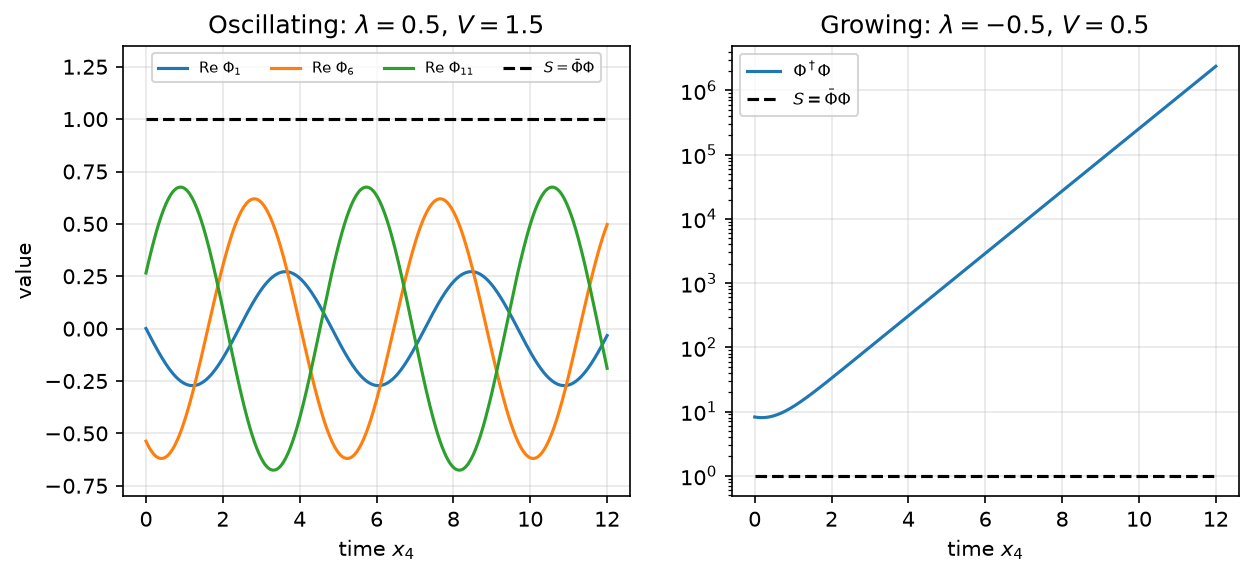

Figure 09b.2 saved as Revision/textbook/figures/09b_2_condensate_solutions.png


In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.9))
phis, S_values = solutions["oscillating"]
for component in (0, 5, 10):  # three of the 16 components (rows 1, 6 and 11)
    left.plot(times, phis[:, component].real,
              label=f"Re $\\Phi_{{{component + 1}}}$")
left.plot(times, S_values, "k--", label="$S = \\bar\\Phi\\Phi$")
left.set_xlabel("time $x_4$")
left.set_ylabel("value")
left.set_ylim(-0.8, 1.35)  # room for the legend above the curves
left.set_title("Oscillating: $\\lambda = 0.5$, $V = 1.5$")
left.legend(fontsize=7, loc="upper center", ncol=4)
phis, S_values = solutions["growing"]
right.plot(times, np.einsum("ti,ti->t", phis.conj(), phis).real,
           label="$\\Phi^\\dagger\\Phi$")
right.plot(times, S_values, "k--", label="$S = \\bar\\Phi\\Phi$")
right.set_yscale("log")
right.set_xlabel("time $x_4$")
right.set_title("Growing: $\\lambda = -0.5$, $V = 0.5$")
right.legend(fontsize=8)
save_figure(fig, "condensate_solutions",
            "Two exact condensates of dirac16complex00 with $m = 1$, $H = 0.25$ and "
            "$S_0 = 1$, for $x_4$ from $0$ to $12$. Left, $\\lambda = 0.5$, so the "
            "effective mass $V = 1.5$ exceeds $3H = 0.75$: the real parts of the "
            "components 1, 6 and 11 of $\\Phi$ oscillate and $S$ (dashed) stays $1$. "
            "Right, $\\lambda = -0.5$, so $V = 0.5 < 3H$: the size "
            "$\\Phi^\\dagger\\Phi$ grows like $e^{2kx_4}$ with $k = 0.559$ "
            "(logarithmic axis) while $S$ (dashed) stays exactly $1$. All values "
            "are pure numbers.")

## 8. Energy density, pressures, kinetic and potential parts of the condensates

For a condensate every kinetic term except $K_4$ vanishes, because every other
derivative is zero. The next cell computes, at every tested time,
$K_4 = \frac12(\bar\Phi\gamma^{(4)}\Phi' - \bar\Phi'\gamma^{(4)}\Phi)$ from the
solution, the Lagrangian $L_0 = K_4 - mS - U$, the energy density
$\rho = -T^{x_4}{}_{x_4} = K_4 - L_0$ and the pressures
$p_\mu = T^\mu{}_\mu = L_0 - K_\mu = L_0$ for $\mu \neq x_4$, which are equal in
all seven directions. It checks $K_4 = VS$, $\rho = mS + \frac{\lambda}{2}S^2$ and
$p = \frac{\lambda}{2}S^2$, hence the kinetic and potential parts
($\rho_{\rm kin} = 0$, $p_{\rm kin} = K_4 = VS$, $p_{\rm pot} = -(mS + U)$), the trace
$-\rho + 7p = -mS + 3\lambda S^2$, and that the $x_4$-$x_8$ component vanishes:
$T^{x_4}{}_{x_8} = -\frac14(B_{48} - \cot z B_{84})$ with
$B_{48} = 0$ (no $x_8$ derivative) and
$B_{84} = \bar\Phi\gamma^{(8)}\Phi' - \bar\Phi'\gamma^{(8)}\Phi$, which must be 0.

In [8]:
def homogeneous_tensor(phi, dphi, lam):
    """K4, rho, p and B84 of a condensate at one time."""
    S = (phi.conj() @ C @ phi).real
    U = lam / 2 * S ** 2
    K4 = 0.5 * (phi.conj() @ C @ g4 @ dphi - dphi.conj() @ C @ g4 @ phi)
    L0 = K4.real - m * S - U  # the other seven kinetic terms are zero
    B84 = phi.conj() @ C @ g8 @ dphi - dphi.conj() @ C @ g8 @ phi
    return S, U, K4, K4.real - L0, L0, B84  # rho = K4 - L0, p = L0


values = {}  # name -> (rho, p) of the condensate
for name, lam in EXAMPLES.items():
    V = m + lam * 1.0
    M, k2 = condensate_matrix(V, H)
    rhos, ps, worst = [], [], 0.0
    for x4 in times:
        phi, dphi = condensate(x4, chi, M, k2)
        S, U, K4, rho, p, B84 = homogeneous_tensor(phi, dphi, lam)
        size = max(1.0, (phi.conj() @ phi).real)  # for relative tolerances
        worst = max(worst, abs(K4.imag) / size, abs(K4.real - V * S) / size,
                    abs(B84) / size)
        rhos.append(rho)
        ps.append(p)
    rhos, ps = np.array(rhos), np.array(ps)
    values[name] = (rhos.mean(), ps.mean())
    check(worst < 1e-12, f"{name}: K4 is real, K4 = V S, and B84 = 0 (T^x4_x8 = 0)")
    check(np.abs(rhos - (m + lam / 2)).max() < 1e-9
          and np.abs(ps - lam / 2).max() < 1e-9,
          f"{name}: rho = m S + lambda S^2/2 and p = lambda S^2/2 at 401 times")
    check(abs(-values[name][0] + 7 * values[name][1] - (-m + 3 * lam)) < 1e-9,
          f"{name}: trace -rho + 7 p = -m S + 3 lambda S^2")
    report(f"{name}: rho", f"{values[name][0]:.6f}")
    report(f"{name}: p (all seven directions)", f"{values[name][1]:.6f}")
    report(f"{name}: w = p/rho", f"{values[name][1] / values[name][0]:.6f}")
check(recorded(THEORY_PY, "commuting_homogeneous_on_shell_rho_p") == "PASS"
      and recorded(THEORY_PY, "commuting_T_x4x8_homogeneous") == "PASS"
      and recorded(THEORY_PY, "commuting_trace_on_shell") == "PASS",
      "these are the record's homogeneous values and its vanishing x4-x8 component",
      record=f"{THEORY_PY}, checks commuting_homogeneous_on_shell_rho_p, "
             "commuting_T_x4x8_homogeneous and commuting_trace_on_shell")

PASS oscillating: K4 is real, K4 = V S, and B84 = 0 (T^x4_x8 = 0)
PASS oscillating: rho = m S + lambda S^2/2 and p = lambda S^2/2 at 401 times
PASS oscillating: trace -rho + 7 p = -m S + 3 lambda S^2
RESULT oscillating: rho = 1.250000
RESULT oscillating: p (all seven directions) = 0.250000
RESULT oscillating: w = p/rho = 0.200000
PASS growing: K4 is real, K4 = V S, and B84 = 0 (T^x4_x8 = 0)
PASS growing: rho = m S + lambda S^2/2 and p = lambda S^2/2 at 401 times
PASS growing: trace -rho + 7 p = -m S + 3 lambda S^2
RESULT growing: rho = 0.750000
RESULT growing: p (all seven directions) = -0.250000
RESULT growing: w = p/rho = -0.333333
PASS these are the record's homogeneous values and its vanishing x4-x8 component
     reproduces Revision/theory/reports/python-field-theory.json, checks
    commuting_homogeneous_on_shell_rho_p, commuting_T_x4x8_homogeneous and
    commuting_trace_on_shell


## 9. Energy density and pressure against S

The next cell draws, for $m = 1$ and $\lambda = 0.5$, the energy density
$\rho = mS + \frac{\lambda}{2}S^2$ and the pressure $p = \frac{\lambda}{2}S^2$ of
a condensate against $S$, with the two parts of the pressure: the kinetic part
$p_{\rm kin} = VS = (m + \lambda S)S$ and the potential part
$p_{\rm pot} = -(mS + U)$. The energy density is zero at $S = 0$ and at
$S = -2m/\lambda = -4$ and negative between them. The cell also checks that the
two parts add up to $p$ at every drawn $S$.

PASS p = p_kin + p_pot = V S - (m S + U) at every drawn S


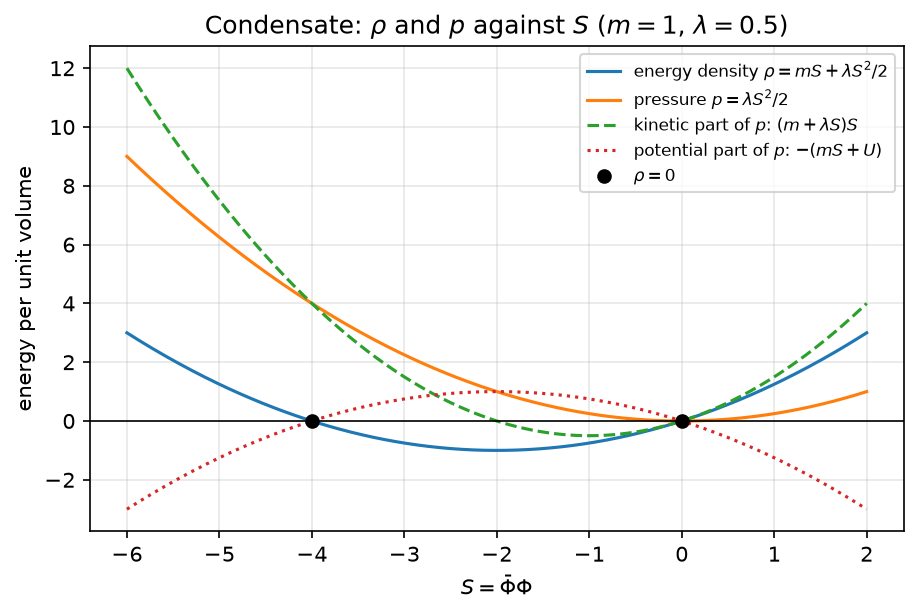

Figure 09b.3 saved as Revision/textbook/figures/09b_3_energy_and_pressure.png


In [9]:
lam = 0.5
S_axis = np.linspace(-6.0, 2.0, 401)
rho_axis = m * S_axis + lam / 2 * S_axis ** 2  # rho = m S + U
p_axis = lam / 2 * S_axis ** 2  # p = S U' - U
p_kin = (m + lam * S_axis) * S_axis  # V S
p_pot = -(m * S_axis + lam / 2 * S_axis ** 2)  # -(m S + U)
check(np.abs(p_kin + p_pot - p_axis).max() < 1e-12,
      "p = p_kin + p_pot = V S - (m S + U) at every drawn S")
fig, ax = plt.subplots()
ax.plot(S_axis, rho_axis, label="energy density $\\rho = mS + \\lambda S^2/2$")
ax.plot(S_axis, p_axis, label="pressure $p = \\lambda S^2/2$")
ax.plot(S_axis, p_kin, "--", label="kinetic part of $p$: $(m + \\lambda S)S$")
ax.plot(S_axis, p_pot, ":", label="potential part of $p$: $-(mS + U)$")
ax.plot([0.0, -2 * m / lam], [0.0, 0.0], "ko", label="$\\rho = 0$")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("$S = \\bar\\Phi\\Phi$")
ax.set_ylabel("energy per unit volume")
ax.set_title("Condensate: $\\rho$ and $p$ against $S$ ($m = 1$, $\\lambda = 0.5$)")
ax.legend(fontsize=8)
save_figure(fig, "energy_and_pressure",
            "Energy density $\\rho = mS + \\lambda S^2/2$ (solid), pressure "
            "$p = \\lambda S^2/2$ (solid) and the two parts of the pressure, the "
            "kinetic part $(m + \\lambda S)S$ (dashed) and the potential part "
            "$-(mS + U)$ (dotted), of a condensate of dirac16complex00 with $m = 1$, "
            "$\\lambda = 0.5$, against $S$ from $-6$ to $2$; vertical axis in units "
            "of energy per unit volume. The energy density vanishes at $S = 0$ and "
            "$S = -2m/\\lambda = -4$ (black dots) and is negative between them; the "
            "pressure is the same in all seven directions.")

## 10. The equation of state of actual solutions

The ratio $w = p/\rho$ depends on $m$, $\lambda$ and $S$ only through
$x = \lambda S/m$: $w = \frac{\lambda S^2/2}{mS + \lambda S^2/2} = \frac{x}{2 + x}$.
The next cell does not use this formula to compute $w$. For twelve values of $x$
it builds the exact condensate with $m = 1$, $S_0 = 1$ and $\lambda = x$, takes
$\Phi$ and $\Phi'$ at the time $x_4 = 1.3$, computes $\rho$ and $p$ from them as
in section 8, and only then compares $p/\rho$ with $x/(2 + x)$. It also finds the
special values: $w = 0$ at $x = 0$ (dust-like), $w = -1$ at $x = -1$, where the
effective mass $V = m + \lambda S$ is zero, $w < -1$ (phantom) for
$-2 < x < -1$, and $w \to 1$ as $x$ grows. At $x = -2$ the energy density is zero
and $w$ is not defined. For $x < -2$ (with $m > 0$ and $S > 0$) the energy
density and the pressure are both negative, and $w > 1$.

In [10]:
x_measured = np.array([-3.5, -3.0, -2.5, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0,
                       4.0])  # values of x = lambda S/m (here lambda = x)
rho_measured, p_measured = [], []  # rho and p of each of the twelve condensates
for x_value in x_measured:
    V = m + x_value * 1.0  # lambda = x_value, S0 = 1
    M, k2 = condensate_matrix(V, H)
    phi, dphi = condensate(1.3, chi, M, k2)
    S, U, K4, rho, p, B84 = homogeneous_tensor(phi, dphi, x_value)
    rho_measured.append(rho)
    p_measured.append(p)
rho_measured, p_measured = np.array(rho_measured), np.array(p_measured)
w_measured = p_measured / rho_measured  # the equation of state of each condensate
w_formula = x_measured / (2 + x_measured)
check(np.abs(w_measured - w_formula).max() < 1e-9,
      "w = p/rho of 12 exact condensates equals x/(2 + x), x = lambda S/m")
at_minus_one = w_measured[list(x_measured).index(-1.0)]
check(abs(at_minus_one + 1.0) < 1e-12,
      "w = -1 exactly where the effective mass m + lambda S vanishes (x = -1)")
below = x_measured < -2  # the three condensates with x < -2
check(np.all(rho_measured[below] < 0) and np.all(p_measured[below] < 0)
      and np.all(w_measured[below] > 1),
      "for x < -2: rho < 0, p < 0 and w > 1")
for x_value, w_value in zip(x_measured, w_measured):
    say(f"x = lambda S/m = {x_value:5.1f}:  w = p/rho = {w_value: .6f}")

PASS w = p/rho of 12 exact condensates equals x/(2 + x), x = lambda S/m
PASS w = -1 exactly where the effective mass m + lambda S vanishes (x = -1)
PASS for x < -2: rho < 0, p < 0 and w > 1
x = lambda S/m =  -3.5:  w = p/rho =  2.333333
x = lambda S/m =  -3.0:  w = p/rho =  3.000000
x = lambda S/m =  -2.5:  w = p/rho =  5.000000
x = lambda S/m =  -1.5:  w = p/rho = -3.000000
x = lambda S/m =  -1.0:  w = p/rho = -1.000000
x = lambda S/m =  -0.5:  w = p/rho = -0.333333
x = lambda S/m =   0.0:  w = p/rho =  0.000000
x = lambda S/m =   0.5:  w = p/rho =  0.200000
x = lambda S/m =   1.0:  w = p/rho =  0.333333
x = lambda S/m =   2.0:  w = p/rho =  0.500000
x = lambda S/m =   3.0:  w = p/rho =  0.600000
x = lambda S/m =   4.0:  w = p/rho =  0.666667


The next cell draws $w = x/(2 + x)$ as a curve, the twelve measured values as
points, and marks the special lines.

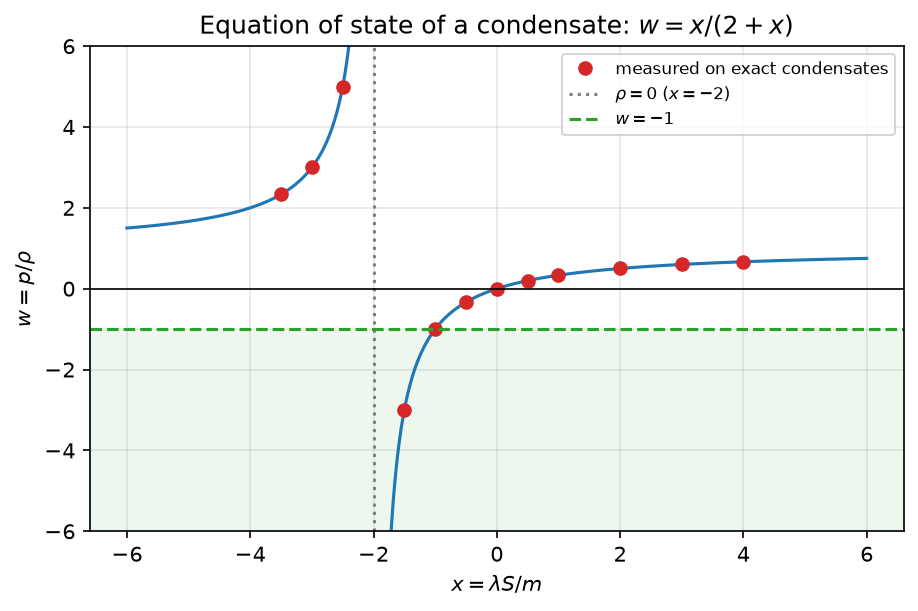

Figure 09b.4 saved as Revision/textbook/figures/09b_4_equation_of_state.png


In [11]:
fig, ax = plt.subplots()
for piece in (np.linspace(-6.0, -2.05, 300), np.linspace(-1.95, 6.0, 500)):
    ax.plot(piece, piece / (2 + piece), color="tab:blue")  # two branches
ax.plot(x_measured, w_measured, "o", color="tab:red",
        label="measured on exact condensates")
ax.axvline(-2.0, color="gray", linestyle=":", label="$\\rho = 0$ ($x = -2$)")
ax.axhline(-1.0, color="tab:green", linestyle="--", label="$w = -1$")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axhspan(-6.0, -1.0, xmin=0.0, xmax=1.0, color="tab:green", alpha=0.08)
ax.set_ylim(-6.0, 6.0)
ax.set_xlabel("$x = \\lambda S / m$")
ax.set_ylabel("$w = p/\\rho$")
ax.set_title("Equation of state of a condensate: $w = x/(2 + x)$")
ax.legend(fontsize=8, loc="upper right")
save_figure(fig, "equation_of_state",
            "Equation of state $w = p/\\rho$ of a condensate of dirac16complex00 "
            "against $x = \\lambda S/m$ (pure numbers): the curve is "
            "$w = x/(2 + x)$, the red points are $p/\\rho$ computed from twelve exact "
            "solutions ($m = 1$, $H = 0.25$, $S_0 = 1$, $\\lambda = x$) and lie on "
            "it. $w = 0$ at $x = 0$, $w = -1$ (dashed) at $x = -1$, where the "
            "effective mass $m + \\lambda S$ vanishes, $w < -1$ (shaded) for "
            "$-2 < x < -1$, $w$ is undefined at $x = -2$ (dotted) where $\\rho = 0$, "
            "$w > 1$ for $x < -2$, where $\\rho$ and $p$ are both negative, "
            "and $w$ approaches $1$ for large $x$. This is the 8-dimensional "
            "ratio, not the equation of state a 3-space observer would infer.")

## 11. Where condensates oscillate and where they grow

A condensate oscillates when $k^2 = 9H^2 - V^2 < 0$, that is when
$|1 + x| > 3H/|m|$ with $x = \lambda S/m$, and grows when $|1 + x| < 3H/|m|$
(because $V = m(1 + x)$). The equation of state depends on $x$ alone, so on the
map of the plane $(x, 3H/|m|)$ every line of constant $w$ is vertical. The next
cell draws the map, the lines $w = -1$, $0$, $1/3$ and the two condensates of
section 7, and checks that each of them lies in the region the map gives.

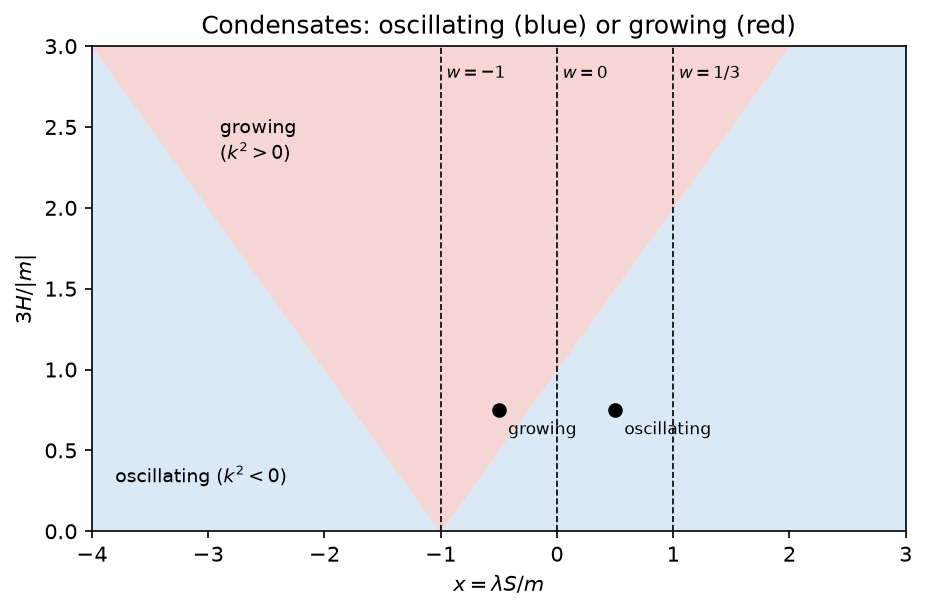

Figure 09b.5 saved as Revision/textbook/figures/09b_5_regime_map.png
PASS the oscillating condensate lies in the oscillating region of the map
PASS the growing condensate lies in the growing region of the map


In [12]:
x_grid = np.linspace(-4.0, 3.0, 701)  # x = lambda S/m
h_grid = np.linspace(0.0, 3.0, 301)  # h = 3 H/|m|
X, Hgrid = np.meshgrid(x_grid, h_grid)  # every pair (x, h) of the two grids
growing_region = (np.abs(1 + X) < Hgrid).astype(float)  # 1 where k^2 > 0
fig, ax = plt.subplots()
ax.contourf(X, Hgrid, growing_region, levels=[-0.5, 0.5, 1.5],
            colors=["#dbe9f6", "#f6d5d5"])
for label, x_line in (("$w = -1$", -1.0), ("$w = 0$", 0.0), ("$w = 1/3$", 1.0)):
    ax.axvline(x_line, color="black", linestyle="--", linewidth=0.8)
    ax.text(x_line + 0.05, 2.8, label, fontsize=8)
for name, lam_value in EXAMPLES.items():
    ax.plot([lam_value * 1.0 / m], [3 * H / abs(m)], "ko")
    ax.text(lam_value / m + 0.08, 3 * H / abs(m) - 0.15, name, fontsize=8)
ax.text(-3.8, 0.3, "oscillating ($k^2 < 0$)", fontsize=9)
ax.text(-2.9, 2.3, "growing\n($k^2 > 0$)", fontsize=9)
ax.set_xlabel("$x = \\lambda S / m$")
ax.set_ylabel("$3H/|m|$")
ax.set_title("Condensates: oscillating (blue) or growing (red)")
ax.grid(False)
save_figure(fig, "regime_map",
            "Map of the condensates of dirac16complex00 in the plane of "
            "$x = \\lambda S/m$ (horizontal) and $3H/|m|$ (vertical), pure numbers. "
            "In the red wedge $|1 + x| < 3H/|m|$ the number $k^2 = 9H^2 - "
            "(m + \\lambda S)^2$ is positive and the condensate grows; in the blue "
            "region it oscillates. The dashed vertical lines are the equations of "
            "state $w = -1$ ($x = -1$), $w = 0$ and $w = 1/3$ ($x = 1$); $w$ "
            "depends on $x$ only. The black dots are the two condensates of the "
            "second figure ($H = 0.25$, $m = 1$). Every condensate with $w = -1$ "
            "lies in the growing wedge.")
for name, lam_value in EXAMPLES.items():
    grows = abs(1 + lam_value / m) < 3 * H / abs(m)
    check(grows == (name == "growing"),
          f"the {name} condensate lies in the {name} region of the map")

## 12. Energy exchange between 3-space and the extra times

Conservation says $d\rho/dx_4 = -3a_4'(p_3 - p_t)$. A condensate has $p_3 = p_t$,
so along every history its energy density stays constant; the next cell confirms
this on the oscillating condensate along the deflating history $a_4 = AHx_4$
($A = 1$): the solution does not depend on $a_4$, and $\rho$ is the same at all
401 times.

In [13]:
A = 1.0  # the deflating history a4 = A H x4
M, k2 = condensate_matrix(m + 0.5 * 1.0, H)  # the oscillating condensate, S0 = 1
# rho at every time; homogeneous_tensor returns (S, U, K4, rho, p, B84): index 3.
# The condensate does not contain a4, so these are its values on this history too.
rho_at_times = np.array([homogeneous_tensor(*condensate(x4, chi, M, k2), 0.5)[3]
                         for x4 in times])
check(np.abs(rho_at_times - rho_at_times[0]).max() < 1e-9,
      "the condensate has p3 = p_t, so its rho is constant along the history")

PASS the condensate has p3 = p_t, so its rho is constant along the history


Then, as an ILLUSTRATION only, the next cell takes toy fluids with assumed
pressures $p_3 = w_3\rho$ and $p_t = w_t\rho$ (constant $w_3$, $w_t$; these are
not solutions of the field equations of this book). The identity becomes
$d\rho/dx_4 = -3AH(w_3 - w_t)\rho$, whose solution is
$\rho = \rho_0 e^{-3AH(w_3 - w_t)x_4}$. The cell solves it numerically with the
Runge-Kutta method (RK4, step $0.05$) for five values of $\Delta w = w_3 - w_t$,
compares with the exact solution (and checks that halving the step divides the
error by about $2^4 = 16$, as it must for a fourth-order method), and checks that
reversing the history ($A \to -A$: the extra times inflate, 3-space deflates)
reverses the flow.

In [14]:
def rk4(rate, y0, step, count):
    """Solve dy/dx = rate(y) from y(0) = y0 with count Runge-Kutta steps."""
    y, path = y0, [y0]
    for _ in range(count):
        s1 = rate(y)
        s2 = rate(y + step / 2 * s1)
        s3 = rate(y + step / 2 * s2)
        s4 = rate(y + step * s3)
        y = y + step / 6 * (s1 + 2 * s2 + 2 * s3 + s4)
        path.append(y)
    return np.array(path)


STEP, COUNT = 0.05, 160  # x4 from 0 to 8
toy_times = STEP * np.arange(COUNT + 1)
DELTAS = (-2 / 3, -1 / 3, 0.0, 1 / 3, 2 / 3)  # Delta w = w3 - w_t
toy = {}  # Delta w -> rho(x4)/rho0 along A = +1
errors = {STEP: 0.0, STEP / 2: 0.0}  # the largest relative error for two steps
for delta in DELTAS:
    for step in errors:
        count = round(8.0 / step)  # the number of steps from x4 = 0 to 8
        path = rk4(lambda r, d=delta: -3 * A * H * d * r, 1.0, step, count)
        exact = np.exp(-3 * A * H * delta * step * np.arange(count + 1))
        errors[step] = max(errors[step], np.abs(path / exact - 1).max())
        if step == STEP:
            toy[delta] = path
check(errors[STEP] < 1e-7,
      "RK4 (step 0.05) reproduces rho0 exp(-3 A H Delta w x4) for 5 toy fluids")
ratio = errors[STEP] / errors[STEP / 2]  # RK4: half the step, 1/16 of the error
check(14 < ratio < 18, "halving the RK4 step divides the error by about 2^4 = 16")
report("largest relative RK4 error, step 0.05", f"{errors[STEP]:.2e}")
report("error ratio of the steps 0.05 and 0.025", f"{ratio:.2f}")
reversed_path = rk4(lambda r: -3 * (-A) * H * (1 / 3) * r, 1.0, STEP, COUNT)
check(np.abs(reversed_path * toy[1 / 3] - 1).max() < 1e-8,
      "A -> -A reverses the energy flow (the product of the two paths is 1)")
report("toy fluid Delta w = 1/3: rho(8)/rho(0) along A = 1", f"{toy[1 / 3][-1]:.6f}")

PASS RK4 (step 0.05) reproduces rho0 exp(-3 A H Delta w x4) for 5 toy fluids
PASS halving the RK4 step divides the error by about 2^4 = 16
RESULT largest relative RK4 error, step 0.05 = 1.33e-08
RESULT error ratio of the steps 0.05 and 0.025 = 16.17
PASS A -> -A reverses the energy flow (the product of the two paths is 1)
RESULT toy fluid Delta w = 1/3: rho(8)/rho(0) along A = 1 = 0.135335


The next cell draws the energy densities of the toy fluids and of the condensate
(left), and for the toy fluid with $(w_3, w_t) = (1/3, 2/3)$, that is
$\Delta w = -1/3$, the two contributions to $d\rho/dx_4$ (right): the term of
the inflating 3-space, $-3a_4'p_3$, which takes energy out, and the term of the
deflating extra times, $+3a_4'p_t$, which puts energy in. Here the second is
twice as large as the first, so $\rho$ grows. For the condensate the two would
be equal and opposite at every time. The cell checks that their sum is the
slope $d\rho/dx_4$ of the drawn path.

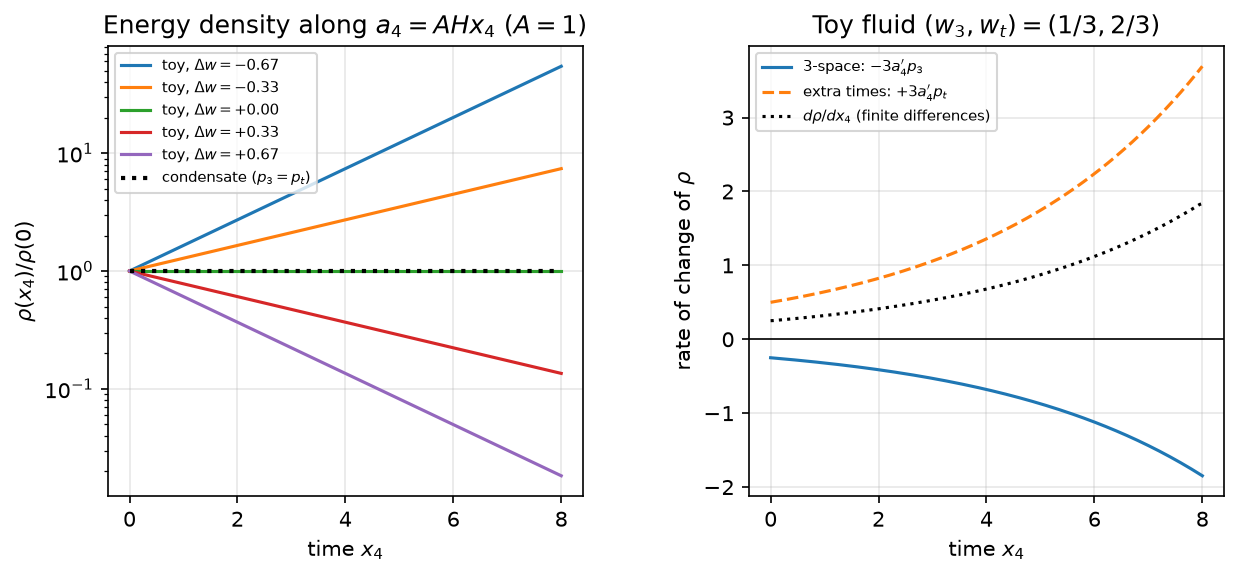

Figure 09b.6 saved as Revision/textbook/figures/09b_6_energy_exchange.png
PASS d rho/dx4 equals the sum of the two work terms on the drawn path


In [15]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.9))
fig.subplots_adjust(wspace=0.35)  # more room between the two panels
for delta in DELTAS:
    left.plot(toy_times, toy[delta], label=f"toy, $\\Delta w = {delta:+.2f}$")
left.plot(times[times <= 8.0], rho_at_times[times <= 8.0] / rho_at_times[0], "k:",
          linewidth=2.0, label="condensate ($p_3 = p_t$)")
left.set_yscale("log")
left.set_xlabel("time $x_4$")
left.set_ylabel("$\\rho(x_4) / \\rho(0)$")
left.set_title("Energy density along $a_4 = AHx_4$ ($A = 1$)")
left.legend(fontsize=7)
rho_toy = toy[-1 / 3]  # Delta w = -1/3: w3 = 1/3, w_t = 2/3
work_space = -3 * A * H * (1 / 3) * rho_toy  # -3 a4' p3 with p3 = rho/3
work_extra = 3 * A * H * (2 / 3) * rho_toy  # +3 a4' p_t with p_t = 2 rho/3
right.plot(toy_times, work_space, label="3-space: $-3a_4' p_3$")
right.plot(toy_times, work_extra, "--", label="extra times: $+3a_4' p_t$")
right.plot(toy_times, np.gradient(rho_toy, toy_times), ":", color="black",
           label="$d\\rho/dx_4$ (finite differences)")
right.axhline(0.0, color="black", linewidth=0.8)
right.set_xlabel("time $x_4$")
right.set_ylabel("rate of change of $\\rho$")
right.set_title("Toy fluid $(w_3, w_t) = (1/3, 2/3)$")
right.legend(fontsize=7)
save_figure(fig, "energy_exchange",
            "Energy exchange along the deflating history $a_4 = AHx_4$, $A = 1$, "
            "$H = 0.25$, for $x_4$ from $0$ to $8$. Left, logarithmic axis: "
            "$\\rho(x_4)/\\rho(0)$ of five toy fluids with assumed pressures "
            "$p_3 = w_3\\rho$, $p_t = w_t\\rho$ and $\\Delta w = w_3 - w_t$ from "
            "$-2/3$ to $2/3$ (an illustration, not solutions of the field "
            "equations), solved with RK4: $\\rho$ falls when $p_3 > p_t$ and rises "
            "when $p_3 < p_t$; the exact condensate (dotted) has $p_3 = p_t$ and "
            "constant $\\rho$. Right: for the toy fluid $(w_3, w_t) = (1/3, 2/3)$ "
            "the term of the inflating 3-space $-3a_4'p_3$ (negative: it takes "
            "energy out), the term of the deflating extra times $+3a_4'p_t$ "
            "(positive and twice as large: it puts energy in) and $d\\rho/dx_4$ "
            "(dotted), which is their sum, so $\\rho$ grows; vertical axis in units "
            "of energy per unit volume per unit time.")
# [2:-2] leaves out two points at each end, where np.gradient is less exact.
check(np.abs(np.gradient(rho_toy, toy_times) - (work_space + work_extra))[2:-2].max()
      < 1e-3, "d rho/dx4 equals the sum of the two work terms on the drawn path")

## 13. The energy of the commuting field has no lower bound

The record proves that the classical energy of dirac16complex00 is unbounded
below already for $U = 0$, with an exact example: in flat 4+4 space (all
$f_a = 1$, no spin connection) with $m = 2$ and the momentum
$(k_1, k_2, k_3, k_8) = (1, 2, 0, 4)$, the plane waves
$\Phi = u e^{i(k_1x_1 + k_2x_2 + k_8x_8 - Ex_4)}$ with $E = 5$ solve the field
equation when $u$ lies in the 8-dimensional eigenspace of the matrix
$h = m\beta + \sum_a k_a\alpha^a$ ($\beta = -i\gamma^{(4)}$,
$\alpha^a = -\gamma^{(4)}\gamma^{(a)}$) with eigenvalue 5, and the energy density
is $\rho = E u^\dagger Bu$. On that eigenspace the form $u^\dagger Bu$ has four
positive and four negative directions (Krein inertia (4,4)). The next cell
builds $h$, checks that it is Hermitian, that $h^2 = 25$ and that it commutes
with $B$, finds its eigenvalues and the eigenspace with eigenvalue 5, and the
inertia of the form $u^\dagger Bu$ on that eigenspace (the eigenvalues of the
$8 \times 8$ matrix of the form).

In [16]:
m_flat, E_flat = 2.0, 5.0
momentum = {0: 1.0, 1: 2.0, 2: 0.0, 7: 4.0}  # k1, k2, k3, k8 (x5, x6, x7: zero)
beta = -1j * g4
h = m_flat * beta + sum(k_a * (-g4 @ gamma[a]) for a, k_a in momentum.items())
check(np.abs(h - h.conj().T).max() < 1e-12 and np.abs(h @ h - 25 * I16).max() < 1e-12
      and np.abs(B @ h - h @ B).max() < 1e-12,
      "h is Hermitian, h^2 = 25, and h commutes with B")
energies, vectors = np.linalg.eigh(h)  # eigenvalues in ascending order
U5 = vectors[:, energies > 0]  # the eight columns with eigenvalue +5
form = U5.conj().T @ B @ U5  # u^dagger B u on the eigenspace, as an 8 x 8 matrix
inertia, directions = np.linalg.eigh(form)
PAIRING = "Revision/pairing/reports/python-pairing.json"
check(np.allclose(energies, [-5.0] * 8 + [5.0] * 8, atol=1e-12)
      and np.allclose(inertia, [-1.0] * 4 + [1.0] * 4, atol=1e-12)
      and recorded(PAIRING, "Q.one_particle_Krein_inertia_proof") == "PASS",
      "E = +-5 (eight each); u^dagger B u has inertia (4,4) on the E = 5 space",
      record=f"{PAIRING}, check Q.one_particle_Krein_inertia_proof (every real "
             "frequency)")

PASS h is Hermitian, h^2 = 25, and h commutes with B
PASS E = +-5 (eight each); u^dagger B u has inertia (4,4) on the E = 5 space
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_Krein_inertia_proof (every real frequency)


The next cell defines `flat_energy_density(u)`, which computes
$\rho = -\sum_{a \neq x_4}K_a + mS$ of the plane wave from its kinetic terms
($\partial_a\Phi = ik_a\Phi$), takes the two eigenvectors of the form with
$Bu = -u$ and $Bu = +u$, checks that each plane wave solves the field equation
$\sum_a\gamma^{(a)}\partial_a\Phi = m\Phi$ of flat space, and checks the record's
values $\rho = -5$ and $\rho = +5$.

In [17]:
def flat_energy_density(u):
    """rho = -sum over a != x4 of K_a + m S for the plane wave u e^(i(k.x - E x4))."""
    S = (u.conj() @ C @ u).real
    kinetic = 0.0
    for a, k_a in momentum.items():  # d_a Phi = i k_a Phi
        d_u = 1j * k_a * u
        kinetic += 0.5 * (u.conj() @ C @ gamma[a] @ d_u - d_u.conj() @ C @ gamma[a] @ u)
    return (-kinetic + m_flat * S).real


rho_pair = []
# column 0 of directions has the eigenvalue -1 of the form, column 7 the value +1
for column, b_value in ((0, -1.0), (7, 1.0)):
    u = U5 @ directions[:, column]  # a unit vector of the eigenspace, B u = b_value u
    d4_u = -1j * E_flat * u  # d4 Phi = -i E Phi
    field = (g4 @ d4_u + sum(gamma[a] @ (1j * k_a * u) for a, k_a in momentum.items())
             - m_flat * u)  # sum_a gamma^(a) d_a Phi - m Phi
    check(np.abs(field).max() < 1e-12 and np.abs(B @ u - b_value * u).max() < 1e-12,
          f"the plane wave with B u = {b_value:+.0f} u solves the field equation")
    rho_pair.append(flat_energy_density(u))
SCOPE_PY = "Revision/theory/reports/python-scope.json"
SCOPE_WL = "Revision/theory/reports/wolfram-scope.json"
check(abs(rho_pair[0] + 5.0) < 1e-12 and abs(rho_pair[1] - 5.0) < 1e-12
      and recorded(SCOPE_PY, "commuting_field_energy_unbounded_below") == "PASS"
      and recorded(SCOPE_WL, "commuting_field_energy_unbounded_below") == "PASS",
      "rho = -5 for B u = -u and rho = +5 for B u = +u (|u| = 1)",
      record=f"{SCOPE_PY} and {SCOPE_WL}, check commuting_field_energy_unbounded_below")

PASS the plane wave with B u = -1 u solves the field equation
PASS the plane wave with B u = +1 u solves the field equation
PASS rho = -5 for B u = -u and rho = +5 for B u = +u (|u| = 1)
     reproduces Revision/theory/reports/python-scope.json and
    Revision/theory/reports/wolfram-scope.json, check
    commuting_field_energy_unbounded_below


The next cell draws 5000 random unit vectors $u$ of the eigenspace (random
combinations of its eight columns, each divided by its length), computes the
energy density of each plane wave from its kinetic terms, and checks that it
equals $E\,u^\dagger Bu$ every time and takes both signs.

In [18]:
samples = rng.normal(size=(5000, 8)) + 1j * rng.normal(size=(5000, 8))
samples /= np.linalg.norm(samples, axis=1)[:, None]
us = samples @ U5.T  # 5000 random unit vectors of the eigenspace
charges = np.einsum("ni,ij,nj->n", us.conj(), B, us).real  # u^dagger B u
rho_samples = np.array([flat_energy_density(u) for u in us])
check(np.abs(rho_samples - E_flat * charges).max() < 1e-12
      and rho_samples.min() < 0 < rho_samples.max(),
      "rho = E u^dagger B u for all 5000 random u of the eigenspace; both signs")
report("smallest and largest rho of the 5000 samples",
       f"{rho_samples.min():.4f} and {rho_samples.max():.4f}")

PASS rho = E u^dagger B u for all 5000 random u of the eigenspace; both signs
RESULT smallest and largest rho of the 5000 samples = -4.3821 and 4.4892


The next cell draws the histogram of the 5000 energy densities.

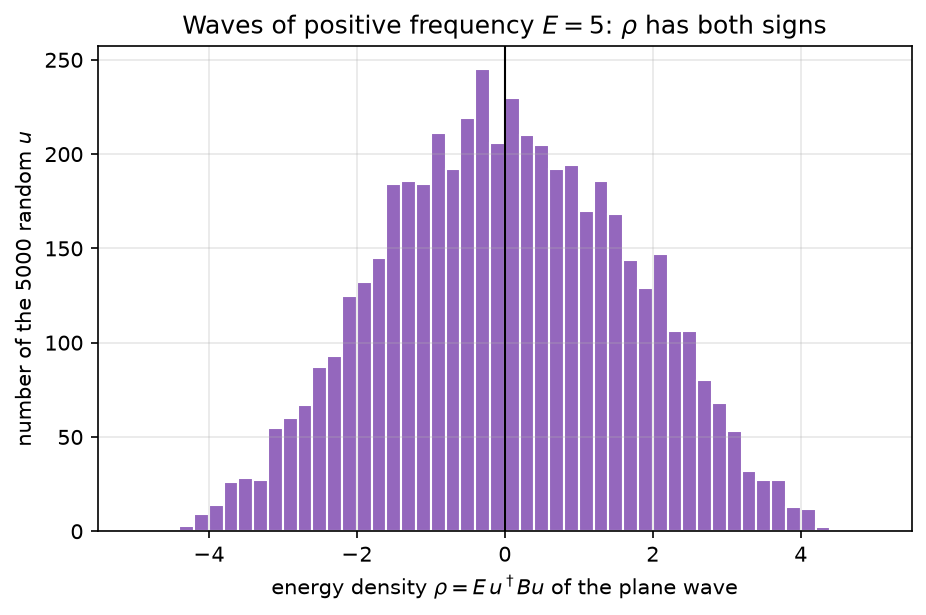

Figure 09b.7 saved as Revision/textbook/figures/09b_7_energy_sign.png


In [19]:
fig, ax = plt.subplots()
ax.hist(rho_samples, bins=50, range=(-5.0, 5.0), color="tab:purple", edgecolor="white")
ax.axvline(0.0, color="black", linewidth=1.0)
ax.set_xlabel("energy density $\\rho = E\\,u^\\dagger B u$ of the plane wave")
ax.set_ylabel("number of the 5000 random $u$")
ax.set_title("Waves of positive frequency $E = 5$: $\\rho$ has both signs")
save_figure(fig, "energy_sign",
            "Histogram of the energy density $\\rho = -\\sum_{a \\neq x_4} K_a + mS$ "
            "of 5000 plane waves $u\\,e^{i(k \\cdot x - Ex_4)}$ of dirac16complex00 "
            "in flat 4+4 space with $m = 2$, $(k_1, k_2, k_3, k_8) = (1, 2, 0, 4)$ "
            "and positive frequency $E = 5$, for random unit vectors $u$ of the "
            "8-dimensional solution space; horizontal axis $\\rho$ in units of "
            "energy per unit volume, vertical axis the count in each of 50 "
            "intervals. Every value equals $E\\,u^\\dagger Bu$; about half are "
            "negative. The possible values fill the whole interval from $-5$ "
            "(reached for $Bu = -u$) to $5$ (for $Bu = u$), but random vectors "
            "seldom come near the two ends: positive frequency does not mean "
            "positive energy for this commuting field.")

## 14. The last check

The last cell checks that the seven figures are saved with their captions and
prints the number of checks that passed.

In [20]:
captions = json.loads(output_file(CAPTION_FILE).read_text(encoding="utf-8"))
expected_files = ["09b_1_sign_of_s.png", "09b_2_condensate_solutions.png",
                  "09b_3_energy_and_pressure.png", "09b_4_equation_of_state.png",
                  "09b_5_regime_map.png", "09b_6_energy_exchange.png",
                  "09b_7_energy_sign.png"]
check(sorted(captions) == expected_files and all(
    output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in expected_files),
    "the seven figures of this notebook are saved and captioned")
all_checks_passed()

PASS the seven figures of this notebook are saved and captioned
ALL 33 CHECKS PASSED (notebook 09b)


## 15. What this notebook showed

- The exact condensates of dirac16complex00,
  $\Phi = (\cosh(kx_4) + \frac{\sinh(kx_4)}{k}M)\chi$ with
  $k^2 = 9H^2 - (m + \lambda S_0)^2$, solve the field equation on every history
  $a_4$; $S$ stays equal to $S_0$, whether the condensate oscillates
  ($k^2 < 0$) or grows ($k^2 > 0$).
- Their energy density and pressure are $\rho = mS + \frac{\lambda}{2}S^2$ and
  $p = \frac{\lambda}{2}S^2$, the same in all seven directions; the kinetic
  energy density is zero, the kinetic pressure is $(m + \lambda S)S$; the
  $x_4$-$x_8$ component vanishes (record values, computed here anew from the
  solutions).
- The equation of state is $w = x/(2 + x)$ with $x = \lambda S/m$, measured on
  twelve exact solutions; $w = -1$ exactly where the effective mass vanishes, and
  such condensates always grow. These $w$ are constant in time and are
  8-dimensional ratios; what a 3-space observer would infer is OPEN in the
  Revision record.
- Because $p_3 = p_t$, a condensate exchanges no energy between 3-space and the
  extra times; toy fluids with $p_3 \neq p_t$ (an illustration) show the exchange
  $d\rho/dx_4 = -3a_4'(p_3 - p_t)$ and its reversal under $A \to -A$.
- $S$ and the energy density of the commuting field have no sign: half of all
  random condensates with $\lambda = 0$ have $\rho < 0$, and positive-frequency
  plane waves have $\rho$ anywhere between $-E$ and $E$ (record:
  `commuting_field_energy_unbounded_below`).
- Status: the exact condensates, their $\rho$ and $p$, the vanishing $x_4$-$x_8$
  component, the energy-exchange identity and the unbounded energy are PROVED in
  the Revision record (exact, Wolfram and sympy); this notebook re-computes them
  numerically (COMPUTED). The toy fluids are an ILLUSTRATION, not solutions. The
  equation of state of a 3-space observer is OPEN. The parameter values are
  choices of this notebook.